# Statistical Modelling Project II: Planning a Term Under Uncertainty

Project I asked what drives exam scores. This project asks a different
question given that model: **how should a student spend a limited term to
get the best result?**

It reuses Project I's fitted coefficients and dataset wherever possible, and
clearly flags every additional number as an assumption made for this project.
The same underlying scenario is modelled at increasing levels of realism:

1. **Scenario**: parameters and what each one is based on.
2. **LP baseline**: the best plan if the world were deterministic and linear.
3. **MDP**: the exact optimal policy once outcomes are uncertain and
   decisions are sequential.
4. **MCTS**: approximate planning by simulation, validated against the MDP's
   exact answer.
5. **Risk-sensitive extension**: maximising the chance of reaching a target
   grade, rather than the average score.
6. **Results**: a side-by-side comparison of all four approaches.
7. **Recommendations**: what the plan means for the student.

Random seed fixed at 42 throughout, so every number here is reproducible.

## 1. Scenario

Every parameter used from here on falls into one of two categories, and both
are kept visibly separate throughout this notebook and in `code/common.py`:

- **From Project I**: a real, fitted number (or a real descriptive statistic
  of Project I's dataset), taken as given.
- **Assumption for this project**: a choice made to turn Project I's
  regression into a concrete planning scenario. Project I never modelled
  decisions or time, so these numbers do not exist anywhere until this
  project defines them.

The one genuinely new descriptive statistic needed at this stage is the mean
weekly study hours across Project I's 320 students. Project I's Group study
and Tutoring effects are a fixed points-per-week bonus for using that method
at all, not a per-hour rate, so Stage 1's hours-allocation linear programme
needs them converted to a per-hour premium. That conversion divides each
dummy coefficient by this mean, which is why it is computed here rather than
simply assumed.

In [1]:
import sys
sys.path.append("../code")

import pandas as pd
import common

df = common.load_student_data()
print(f"Students in Project I's dataset: {len(df)}")
print(f"Mean weekly study hours: {common.MEAN_WEEKLY_STUDY_HOURS}")
df.head()

Students in Project I's dataset: 320
Mean weekly study hours: 11.9094


,student_id,study_hours_per_week,attendance_rate,sleep_hours,prior_gpa,extracurricular_hours,study_method,exam_score
0,S0001,13.28,66.5,7.48,3.38,1,Group study,53.2
1,S0002,6.53,77.5,6.68,2.79,3,Self-study,58.6
2,S0003,15.69,92.8,6.81,3.62,5,Self-study,92.0
3,S0004,8.39,82.9,5.91,3.18,4,Self-study,67.3
4,S0005,11.22,70.1,8.14,2.94,3,Self-study,56.9


### Parameter table: from Project I vs assumption for this project

The table below is generated directly from `code/common.py`, so it can never
drift out of sync with the values the rest of this notebook actually uses.

In [2]:
rows = [
    ("Mean weekly study hours", common.MEAN_WEEKLY_STUDY_HOURS, "From Project I (dataset mean)"),
    ("Study hours coefficient (points per hour)", common.PROJECT_I_STUDY_HOURS_COEF, "From Project I (fitted)"),
    ("Attendance coefficient (points per pp)", common.PROJECT_I_ATTENDANCE_COEF, "From Project I (fitted)"),
    ("Prior GPA coefficient (points per GPA point)", common.PROJECT_I_PRIOR_GPA_COEF, "From Project I (fitted)"),
    ("Extracurricular coefficient (points per hour)", common.PROJECT_I_EXTRACURRICULAR_COEF, "From Project I (fitted)"),
    ("Group study dummy (points per week)", common.PROJECT_I_GROUP_STUDY_DUMMY, "From Project I (fitted)"),
    ("Tutoring dummy (points per week)", common.PROJECT_I_TUTORING_DUMMY, "From Project I (fitted)"),
    ("Sleep coefficient, estimated (not significant)", common.PROJECT_I_SLEEP_COEF_ESTIMATED, "From Project I (fitted)"),
    ("Sleep penalty, true generating value", common.TRUE_SLEEP_PENALTY_PER_HOUR_BELOW_6, "From Project I (true, generating)"),
    ("Exam score noise SD", common.TRUE_NOISE_SD, "From Project I (true, generating)"),
    ("Group study premium per hour", round(common.LP_GROUP_STUDY_PREMIUM_PER_HOUR, 4), "Assumption (derived: dummy / mean hours)"),
    ("Tutoring premium per hour", round(common.LP_TUTORING_PREMIUM_PER_HOUR, 4), "Assumption (derived: dummy / mean hours)"),
    ("Weekly hours budget", common.LP_TOTAL_HOURS_BUDGET, "Assumption"),
    ("Tutoring hours cap", common.LP_TUTORING_MAX_HOURS, "Assumption"),
    ("Group study hours cap", common.LP_GROUP_STUDY_MAX_HOURS, "Assumption"),
    ("Scheduled lecture hours", common.LP_SCHEDULED_LECTURE_HOURS, "Assumption"),
    ("Extracurricular minimum hours", common.LP_EXTRACURRICULAR_MIN_HOURS, "Assumption"),
    ("Term length (weeks)", common.MDP_TERM_WEEKS, "Assumption"),
    ("Knowledge scale (0 to k_max)", common.MDP_KNOWLEDGE_MAX, "Assumption"),
    ("Tutoring sessions available", common.MDP_TUTORING_SESSIONS_MAX, "Assumption"),
    ("Starting state (t, k, f, s)", tuple(common.MDP_START_STATE.values()), "Assumption"),
    ("P(self-study gains +1 knowledge)", common.MDP_P_SELF_STUDY, "Assumption (baseline)"),
    ("P(group study gains +1 knowledge)", common.MDP_P_GROUP_STUDY, "Assumption (ratio anchored to Project I)"),
    ("P(tutoring gains +1 / +2 knowledge)", (common.MDP_P_TUTORING_PLUS1, common.MDP_P_TUTORING_PLUS2), "Assumption (ratio anchored to Project I)"),
    ("Fatigue success multipliers (fresh, tired, exhausted)", tuple(common.MDP_FATIGUE_FACTOR.values()), "Assumption"),
    ("P(studying raises fatigue by 1)", common.MDP_P_FATIGUE_INCREASE, "Assumption"),
    ("Terminal score at k = 0 / k = 10", (common.terminal_expected_score(0), common.terminal_expected_score(10)), "Assumption (calibrated to Project I's score range)"),
    ("Risk-sensitive target grade", common.RISK_TARGET_GRADE, "Assumption (example: a scholarship threshold)"),
]
param_table = pd.DataFrame(rows, columns=["Parameter", "Value", "Source"])
param_table

,Parameter,Value,Source
0,Mean weekly study hours,11.9094,From Project I (dataset mean)
1,Study hours coefficient (points per hour),1.13,From Project I (fitted)
2,Attendance coefficient (points per pp),0.28,From Project I (fitted)
3,Prior GPA coefficient (points per GPA point),7.73,From Project I (fitted)
4,Extracurricular coefficient (points per hour),-0.52,From Project I (fitted)
5,Group study dummy (points per week),1.83,From Project I (fitted)
6,Tutoring dummy (points per week),5.56,From Project I (fitted)
7,"Sleep coefficient, estimated (not significant)",0.4,From Project I (fitted)
8,"Sleep penalty, true generating value",-1.8,"From Project I (true, generating)"
9,Exam score noise SD,7.5,"From Project I (true, generating)"


## 2. LP baseline

**Plain-language finding first:** if hours simply added up with no diminishing
returns and no uncertainty, the best plan is not a balanced spread. It is to
max out every capped, high-value activity (lecture, tutoring, group study)
and pour every remaining hour into self-study, hitting the weekly budget
exactly. That "all or nothing" shape, not a balanced timetable, is the
signature of a linear model, and it is the reason Stage 2 introduces
diminishing returns and uncertainty.

### The linear programme

Decision variables (hours per week): self-study $x_1$, group study $x_2$,
tutoring $x_3$, lecture $x_4$, extracurricular $x_5$.

$$
\begin{aligned}
\text{maximise} \quad & 1.13 x_1 + 1.2837 x_2 + 1.5969 x_3 + 1.8667 x_4 - 0.52 x_5 \\
\text{subject to} \quad & x_1 + x_2 + x_3 + x_4 + x_5 \le 40 \\
& x_3 \le 3 \\
& x_2 \le 6 \\
& x_4 \le 15 \\
& x_5 \ge 2 \\
& x_1, x_2, x_3, x_4, x_5 \ge 0
\end{aligned}
$$

The coefficients on $x_2$ and $x_3$ are Project I's Group study and Tutoring
bonuses (a fixed points-per-week premium for using that method at all)
converted to a per-hour premium by dividing by the mean weekly study hours
in Project I's dataset (an assumption for this project, documented in
`common.py`). The coefficient on $x_4$ is Project I's attendance coefficient
rescaled from percentage points to lecture hours, given 15 scheduled hours a
week.

In [3]:
import importlib
lp = importlib.import_module("01_lp")

result, coefs, A_ub, b_ub = lp.build_lp()
allocation = dict(zip(lp.VARS, result.x))
for v in lp.VARS:
    print(f"{lp.VAR_LABELS[v]}: {allocation[v]:.1f} hours")
print(f"\nPredicted score: {lp.predicted_score(allocation):.2f}")

Self-study: 14.0 hours
Group study: 6.0 hours
Tutoring: 3.0 hours
Lecture: 15.0 hours
Extracurricular: 2.0 hours

Predicted score: 66.23


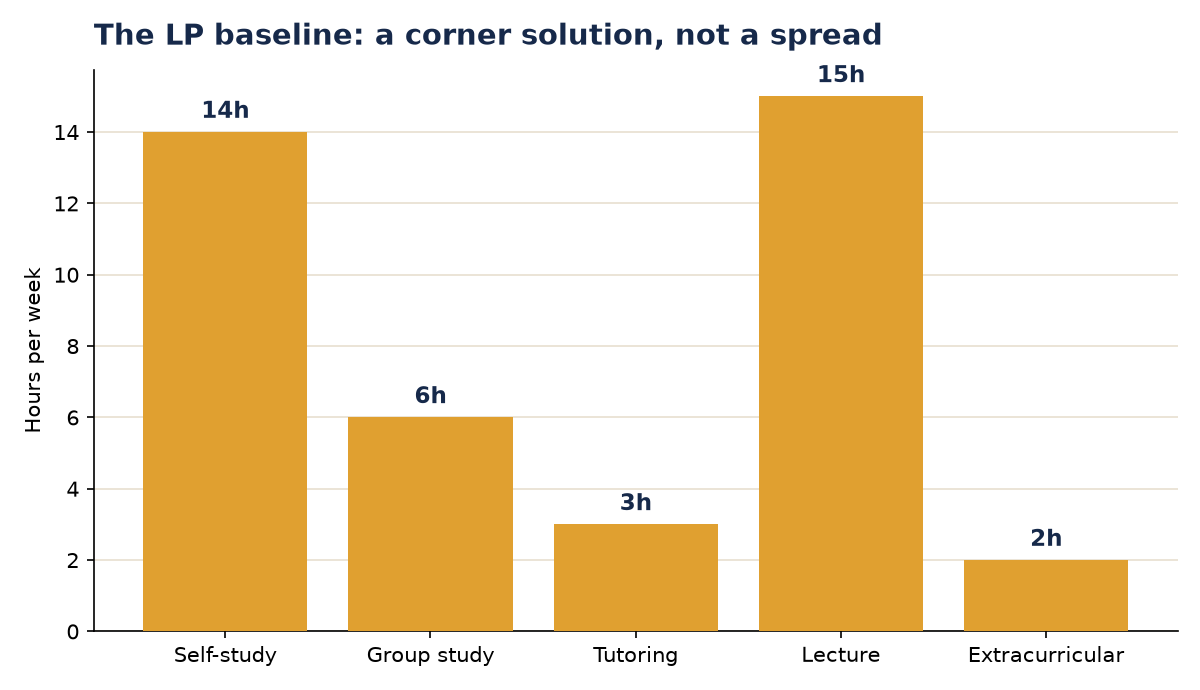

In [4]:
lp.plot_allocation(allocation, "../images/01_lp_allocation.png")
from IPython.display import Image
Image("../images/01_lp_allocation.png")

### Shadow prices: what one more hour of each resource is worth

A shadow price is the rate of change in the optimal score if a constraint
were relaxed by one unit, holding everything else fixed.

In [5]:
shadow = lp.shadow_prices(result)
for name, price in shadow.items():
    print(f"{name}: {price:+.4f} points")

Weekly hours budget: +1.1300 points
Tutoring hours cap: +0.4669 points
Group study hours cap: +0.1537 points
Lecture hours cap: +0.7367 points
Extracurricular minimum: +1.6500 points


In plain words: the weekly hours budget is worth **1.13 points per extra
hour**, exactly the self-study rate, because self-study is the activity
still absorbing spare hours once everything else is capped or at its
minimum. Relaxing the tutoring cap by one session is worth **0.4669
points**, the premium tutoring has over self-study. The extracurricular
minimum is the most expensive constraint by far, at **1.65 points per
hour** were it relaxed downward, since every hour freed from
extracurricular both stops losing 0.52 points and starts earning 1.13
points at self-study, a swing of 1.65.

### Validation

Two independent checks, plus a numeric constraint check.

In [6]:
# Check 1: shadow price of the weekly budget, confirmed by re-solving at 41 hours
result41, _, _, _ = lp.build_lp(41)
allocation41 = dict(zip(lp.VARS, result41.x))
score_40 = lp.predicted_score(allocation)
score_41 = lp.predicted_score(allocation41)
print(f"Score at 40 hours: {score_40:.4f}")
print(f"Score at 41 hours: {score_41:.4f}")
print(f"Actual increase: {score_41 - score_40:.4f}")
print(f"Shadow price predicted: {shadow['Weekly hours budget']:.4f}")
print(f"Match: {abs((score_41 - score_40) - shadow['Weekly hours budget']) < 1e-6}")

Score at 40 hours: 66.2325
Score at 41 hours: 67.3625
Actual increase: 1.1300
Shadow price predicted: 1.1300
Match: True


In [7]:
# Check 2: coarse brute-force grid search over feasible allocations
grid = lp.brute_force_grid_search()
lp_decision_score = lp.predicted_score(allocation) - lp.common.PROJECT_I_INTERCEPT
print(f"Grid search best decision-only score: {grid['decision_score']:.4f}")
print(f"LP decision-only score:               {lp_decision_score:.4f}")
print(f"Match: {abs(grid['decision_score'] - lp_decision_score) < 1e-6}")

Grid search best decision-only score: 55.2725
LP decision-only score:               55.2725
Match: True


In [8]:
# Check 3: every constraint satisfied numerically
total_hours = sum(allocation.values())
print(f"Total hours used: {total_hours:.4f} (budget 40): {total_hours <= 40 + 1e-9}")
print(f"Tutoring: {allocation['tutoring']:.4f} (cap 3): {allocation['tutoring'] <= 3 + 1e-9}")
print(f"Group study: {allocation['group_study']:.4f} (cap 6): {allocation['group_study'] <= 6 + 1e-9}")
print(f"Lecture: {allocation['lecture']:.4f} (cap 15): {allocation['lecture'] <= 15 + 1e-9}")
print(f"Extracurricular: {allocation['extracurricular']:.4f} (min 2): {allocation['extracurricular'] >= 2 - 1e-9}")
print(f"All non-negative: {all(v >= -1e-9 for v in allocation.values())}")

Total hours used: 40.0000 (budget 40): True
Tutoring: 3.0000 (cap 3): True
Group study: 6.0000 (cap 6): True
Lecture: 15.0000 (cap 15): True
Extracurricular: 2.0000 (min 2): True
All non-negative: True


### Sensitivity: how the optimal score changes with the weekly budget

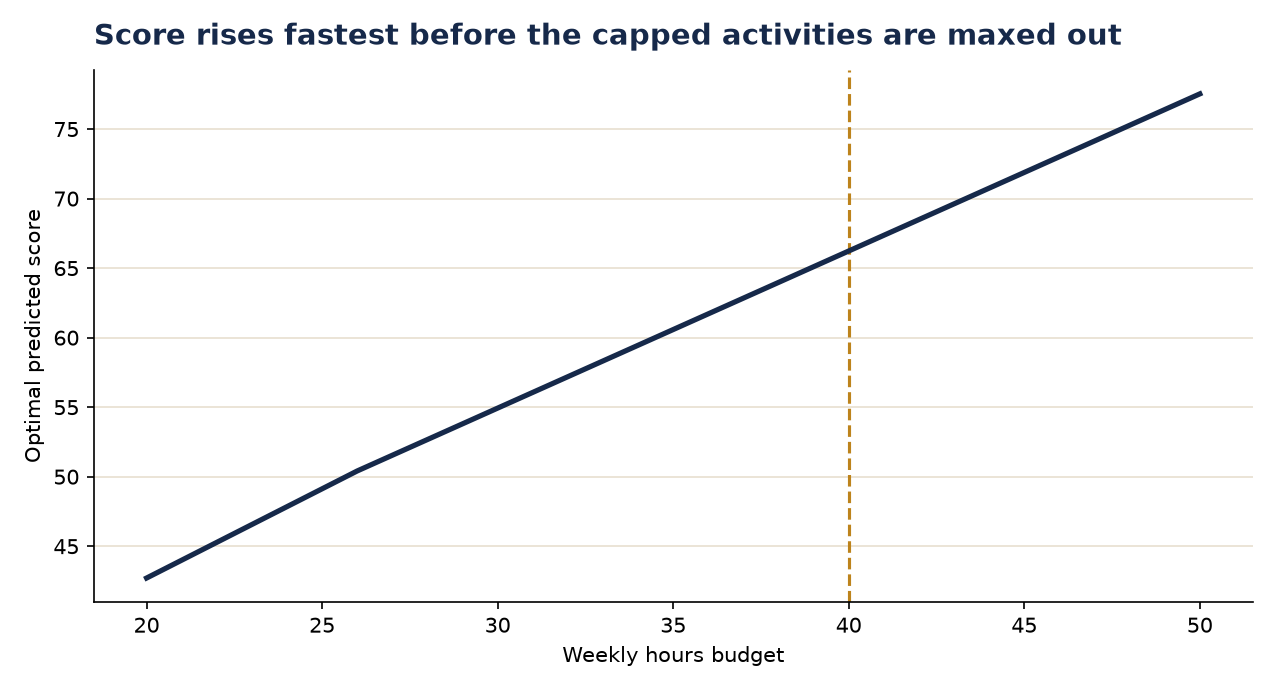

In [9]:
sweep = lp.sensitivity_sweep()
lp.plot_sensitivity(sweep, "../images/02_lp_sensitivity.png")
Image("../images/02_lp_sensitivity.png")

### Why this motivates Stage 2

The LP's answer is a corner solution: every hour flows to the
highest-return activity until a constraint binds, then the next
highest, and so on, with nothing left in reserve. That happens because
the objective is linear (no diminishing returns to an hour of tutoring,
no cost to sequencing) and there is no uncertainty (an hour of self-study
always returns exactly 1.13 points). Neither is true of an actual term:
fatigue makes additional study less effective, study can fail to produce
learning at all, and a student's state (how much they already know, how
tired they are, how many tutoring sessions remain) changes week to week.
Stage 2 models the same scenario as a sequential decision problem under
uncertainty, which is where a corner solution stops being the obvious
answer.

## 3. MDP

**Plain-language finding first:** the optimal policy is not "study as much as
possible". It is "study with the highest-success-rate action available, and
rest first when there is enough term left to recover, since a fresh student
learns far more per session than a tired one." A second, more surprising
finding: self-study is never the optimal choice anywhere in the 2,145-state
policy, because in this scenario group study carries no weekly capacity
limit (unlike Stage 1's 6-hour cap) and has a strictly higher success
probability, so it dominates self-study completely. That is a real property
of this model, not a bug, and it is discussed after the results below.

### The state, and the Bellman equation

State $(t, k, f, s)$: week $t \in \{0, \dots, 12\}$, knowledge
$k \in \{0, \dots, 10\}$, fatigue $f \in \{0, 1, 2\}$, tutoring sessions
remaining $s \in \{0, \dots, 4\}$. Actions $a \in A(s)$: self-study, group
study, rest, and tutoring only when $s > 0$.

$$
V_t(k, f, s) = \max_{a \in A(s)} \; \mathbb{E}_{(k', f', s') \sim P(\cdot \mid k, f, s, a)} \big[ V_{t+1}(k', f', s') \big], \qquad t = 0, \dots, 11
$$
$$
V_{12}(k, f, s) = \text{clip}(a + b k,\ 0,\ 100) \quad \text{for all } f, s
$$

In plain words: the value of a state is the best you can do from here, and
the best you can do is the action whose *average* future value, over every
random outcome it could produce, is highest. Working backward from the
last week (where the value is just the terminal score) to the first,
this equation is solved exactly at every one of the 2,145 states, which is
what backward induction means in practice.

In [10]:
import importlib
mdp = importlib.import_module("02_mdp")

V, policy, solve_seconds = mdp.solve()
n_states_per_week = len(list(mdp.all_states()))
n_state_values = n_states_per_week * (mdp.T_MAX + 1)
print(f"States per week: {n_states_per_week}")
print(f"State-values solved (across {mdp.T_MAX + 1} weeks): {n_state_values}")
print(f"Solve time: {solve_seconds:.4f} seconds")

start = (mdp.common.MDP_START_STATE["k"], mdp.common.MDP_START_STATE["f"], mdp.common.MDP_START_STATE["s"])
v_start = V[0][start]
print(f"\nV*(start) = {v_start:.4f}")

States per week: 165
State-values solved (across 13 weeks): 2145
Solve time: 0.0181 seconds

V*(start) = 81.9763


### Validation

In [11]:
# Check (a): V at t = 12 equals the terminal reward exactly
check_a = all(
    abs(V[mdp.T_MAX][state] - mdp.common.terminal_expected_score(state[0])) < 1e-9
    for state in mdp.all_states()
)
print(f"Check (a), V at t=12 equals the terminal reward for every state: {check_a}")

Check (a), V at t=12 equals the terminal reward for every state: True


In [12]:
import numpy as np

rng = np.random.default_rng(mdp.common.SEED)
n_sims = 10_000

scores_optimal = mdp.simulate_policy(mdp.optimal_policy_fn(policy), n_sims, rng, start)
mean_optimal = scores_optimal.mean()
se_optimal = scores_optimal.std(ddof=1) / np.sqrt(n_sims)
ci_low, ci_high = mean_optimal - 1.96 * se_optimal, mean_optimal + 1.96 * se_optimal

print(f"Check (b): simulated mean final score under the optimal policy ({n_sims} terms): {mean_optimal:.4f}")
print(f"95 percent CI: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"V*(start) = {v_start:.4f} falls inside this CI: {ci_low <= v_start <= ci_high}")

Check (b): simulated mean final score under the optimal policy (10000 terms): 82.0070
95 percent CI: [81.8452, 82.1688]
V*(start) = 81.9763 falls inside this CI: True


In [13]:
fixed_policies = {
    "Always self-study": mdp.always_self_study_fn(),
    "Always tutoring": mdp.always_tutoring_fn(),
    "Alternate study/rest": mdp.alternate_study_rest_fn(),
}
results = {"Optimal (MDP)": scores_optimal}
for name, fn in fixed_policies.items():
    results[name] = mdp.simulate_policy(fn, n_sims, rng, start)

print("Check (c): optimal policy against three simple fixed policies")
for name, scores in results.items():
    print(f"  {name}: mean {scores.mean():.4f}")

beats_all = all(scores_optimal.mean() >= results[name].mean() for name in fixed_policies)
print(f"\nOptimal beats every fixed policy: {beats_all}")

Check (c): optimal policy against three simple fixed policies
  Optimal (MDP): mean 82.0070
  Always self-study: mean 71.7070
  Always tutoring: mean 75.1455
  Alternate study/rest: mean 70.1120

Optimal beats every fixed policy: True


### Policy heatmaps

Each heatmap fixes fatigue and tutoring sessions remaining, and shows the
optimal action across every combination of week and knowledge.

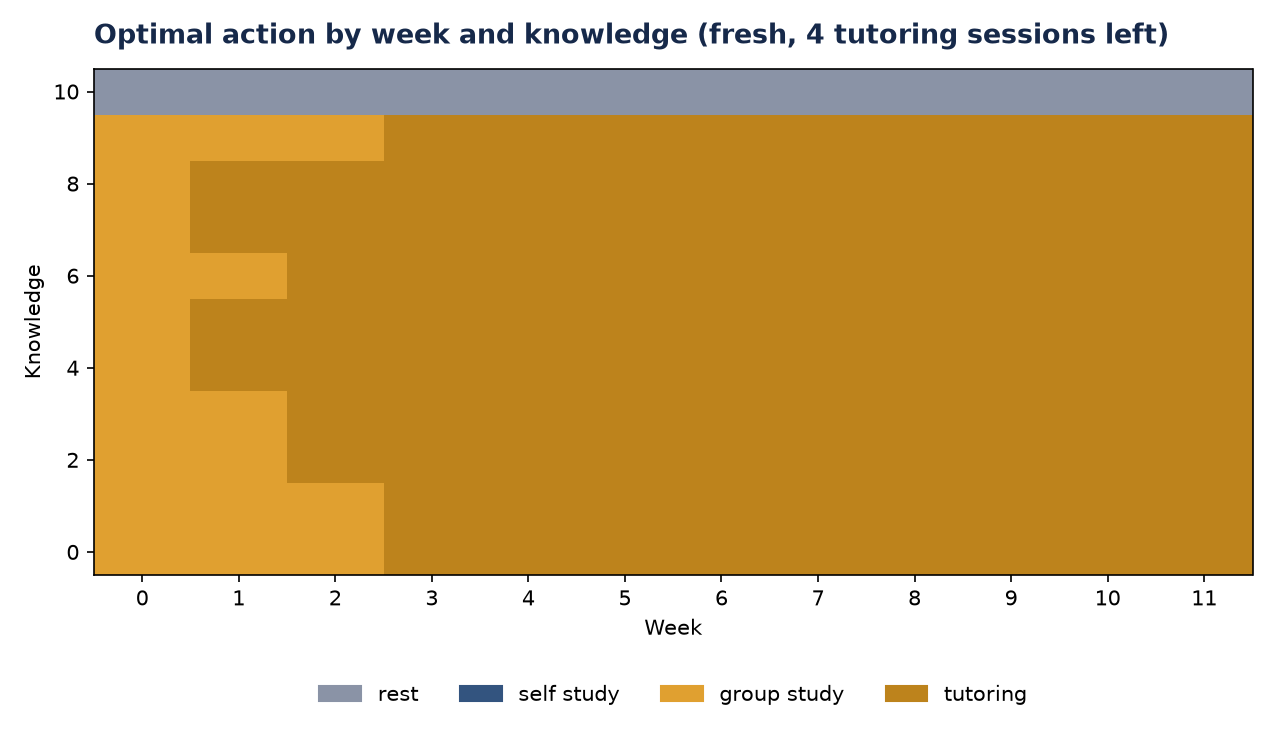

In [14]:
from IPython.display import Image

mdp.plot_policy_heatmap(policy, f=0, s=4, path="../images/03_mdp_policy_fresh_full_sessions.png",
                          title="Optimal action by week and knowledge (fresh, 4 tutoring sessions left)")
Image("../images/03_mdp_policy_fresh_full_sessions.png")

Fresh, with tutoring sessions available, the policy studies from week 0:
group study while knowledge is still low, tutoring for almost the entire
rest of the term once sessions are worth spending. Rest never appears here,
because there is no fatigue to recover from yet.

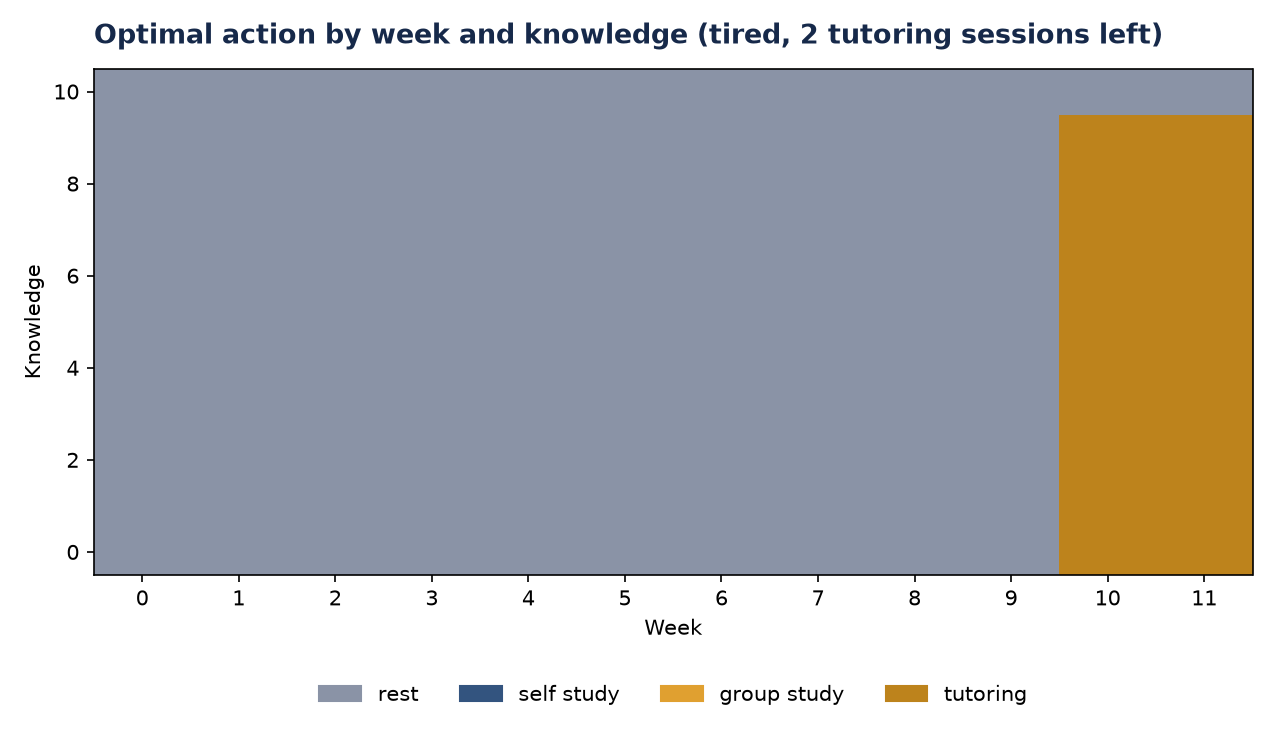

In [15]:
mdp.plot_policy_heatmap(policy, f=1, s=2, path="../images/04_mdp_policy_tired_some_sessions.png",
                          title="Optimal action by week and knowledge (tired, 2 tutoring sessions left)")
Image("../images/04_mdp_policy_tired_some_sessions.png")

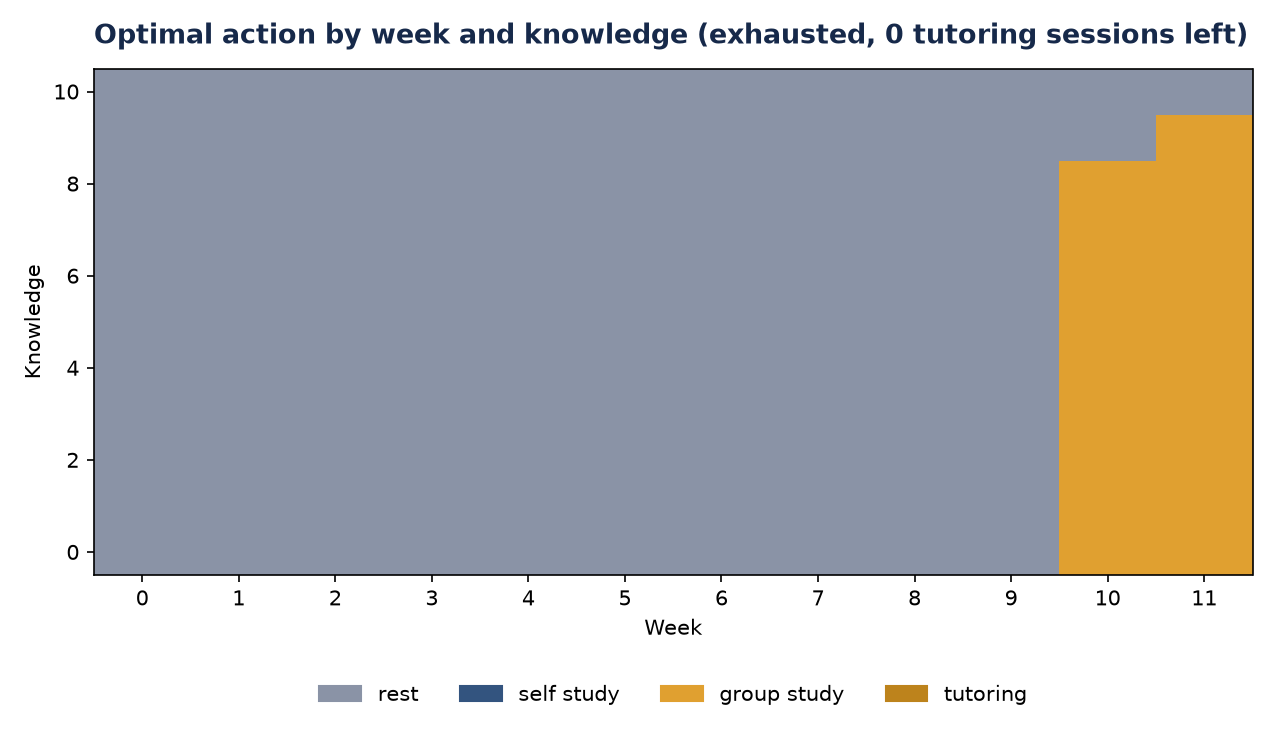

In [16]:
mdp.plot_policy_heatmap(policy, f=2, s=0, path="../images/05_mdp_policy_exhausted_no_sessions.png",
                          title="Optimal action by week and knowledge (exhausted, 0 tutoring sessions left)")
Image("../images/05_mdp_policy_exhausted_no_sessions.png")

Starting tired or exhausted with most of the term still ahead, the policy
rests for almost the entire term, then studies intensively only in the
final two or three weeks. That is not passivity: a fresh student succeeds
far more often per session (fatigue multiplies success probability by
0.75 when tired, 0.4 when exhausted), so recovering fatigue early and
cramming with full effectiveness near the end outperforms studying
continuously at reduced effectiveness throughout. Once too few weeks
remain for that trade-off to pay off, the policy switches straight to
study.

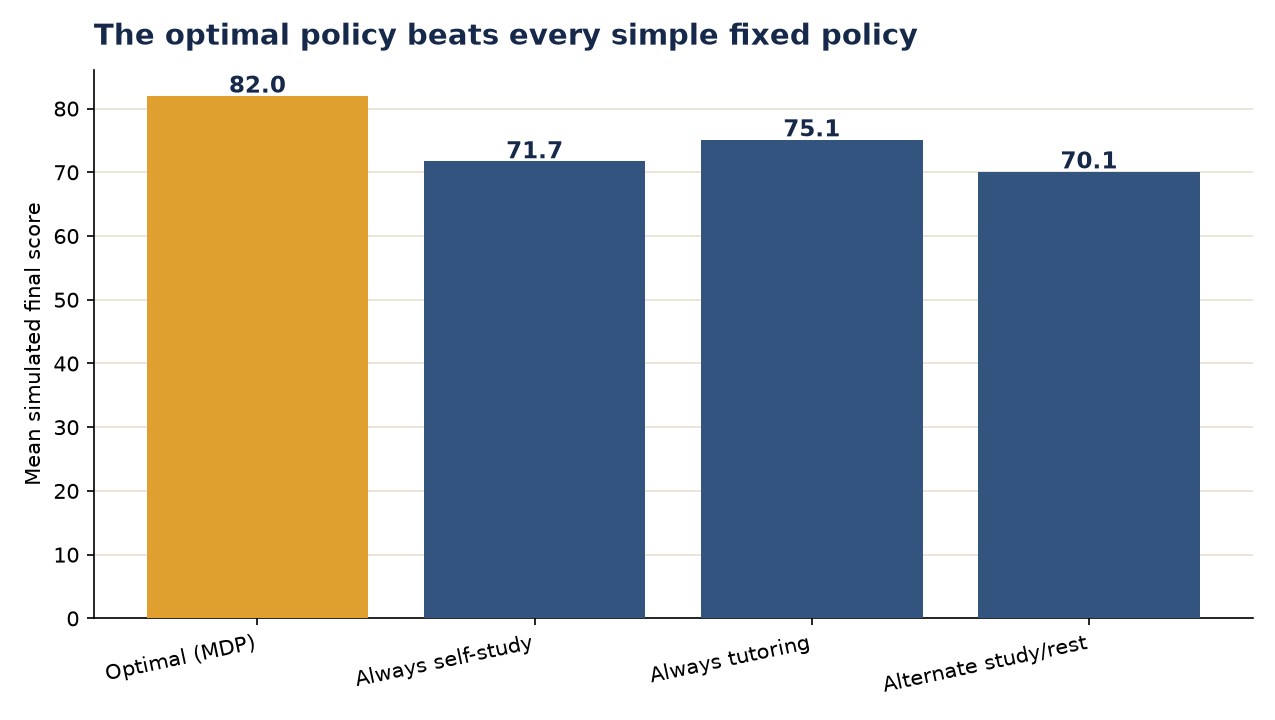

In [17]:
mdp.plot_policy_comparison(results, "../images/06_mdp_policy_comparison.png")
Image("../images/06_mdp_policy_comparison.png")

### Why self-study never appears

Across all 2,145 states, the optimal policy never chooses self-study. This
is a real consequence of how this scenario is built, not an error: Stage
1's linear programme capped group study at 6 hours a week, but Stage 2's
weekly action choice carries no such capacity limit on group study. With
group study both uncapped and higher-probability than self-study (0.57
against 0.50), it weakly dominates self-study in every state, so an exact
solver never picks the dominated option. A more realistic MDP would give
group study a capacity or availability constraint of its own; that is
flagged here rather than patched, since changing it now would be tuning
the model to produce a more expected-looking answer rather than reporting
what this model actually does.

## 4. MCTS

**Plain-language finding first:** Monte Carlo tree search, given only the
simulator and never the exact answer, picks the same action as the exact
optimal policy about three quarters of the time, and its mistakes are
nearly free (a fraction of a point lost, on average) rather than costly.
Its own estimate of *how good* a state is converges toward the true value
as the search budget grows, but only slowly, since a 12 week horizon with
several stochastic outcomes per action is a large tree to explore and
20,000 simulations still leaves a real, measured gap. Both of these are
reported as found.

### Why chance is folded into the tree rather than modelled separately

Every action here has several possible outcomes (self-study can succeed
or not, and independently make the student more tired or not). Rather
than adding a second node type for "chance", each action's children are
keyed by the specific next state a simulation actually sampled. The first
time an action produces a new outcome, a new child is created for it;
if a later simulation samples that same outcome again, it reuses the
existing child. Run enough simulations and the mix of children under an
action naturally reflects the environment's real transition
probabilities, without ever writing those probabilities into the tree by
hand. This is simpler to implement than explicit chance nodes and is
exactly as correct for this problem, since every action here always leads
to one of a small, fixed set of next states.

### UCB1: the exploration and exploitation trade-off

$$
\text{UCB1}(a) = \bar{Q}(a) + c \sqrt{\dfrac{\ln N}{N(a)}}
$$

$\bar{Q}(a)$ is the average return seen so far from trying action $a$ at
this node (exploitation: keep doing what has worked). The second term
grows whenever an action has been tried relatively rarely ($N(a)$ small)
compared to the node overall ($N$), pulling search back toward
under-explored actions before the tree commits too early to an action
that only looked good by chance (exploration). $c$ controls the balance.
Classic UCB1 sets $c = \sqrt{2}$ for rewards scaled to $[0, 1]$; this
problem's terminal rewards span roughly 45 to 95, so that constant would
barely explore at all. A small sweep across candidate values of $c$
against the known exact value (see `DEBUG_LOG.md`) settled on $c = 5$.

In [18]:
import importlib
import numpy as np

mcts = importlib.import_module("03_mcts")

rng = np.random.default_rng(42)
root = mcts.run_mcts(0, start, budget=5000, rng=rng)
print(f"MCTS root value estimate: {mcts.root_value(root):.4f}")
print(f"MCTS action Q-values: { {a: round(q, 2) for a, q in mcts.action_q_values(root).items()} }")
print(f"MCTS recommended action: {mcts.recommended_action(root)}")
print(f"\nExact V*(start): {V[0][start]:.4f}")
print(f"Exact optimal action: {policy[0][start]}")

MCTS root value estimate: 76.5810
MCTS action Q-values: {'self_study': 70.0, 'tutoring': 76.6, 'group_study': 70.71, 'rest': 65.0}
MCTS recommended action: tutoring

Exact V*(start): 81.9763
Exact optimal action: group_study


Even at the very first decision, MCTS and the exact solution disagree:
MCTS recommends tutoring, the exact policy says group study. The gap
between these two actions' true values is small (both are near the top
of a close field, as the Q-values above show), but it is a genuine
disagreement, not a rounding artefact, and it recurs in the systematic
check below.

### Convergence: does more search find the true value?

In [19]:
conv_df = mcts.convergence_experiment(start)
conv_df.to_csv("../data/mcts_convergence.csv", index=False)
print(conv_df.groupby("budget").root_value.agg(["mean", "sem"]))
v_star = V[0][start]
print(f"\nV*(start) = {v_star:.4f}")

            mean       sem
budget                    
100     74.51750  0.225373
500     75.35850  0.121327
1000    75.49250  0.114259
5000    76.18315  0.064119
20000   76.85265  0.056197

V*(start) = 81.9763


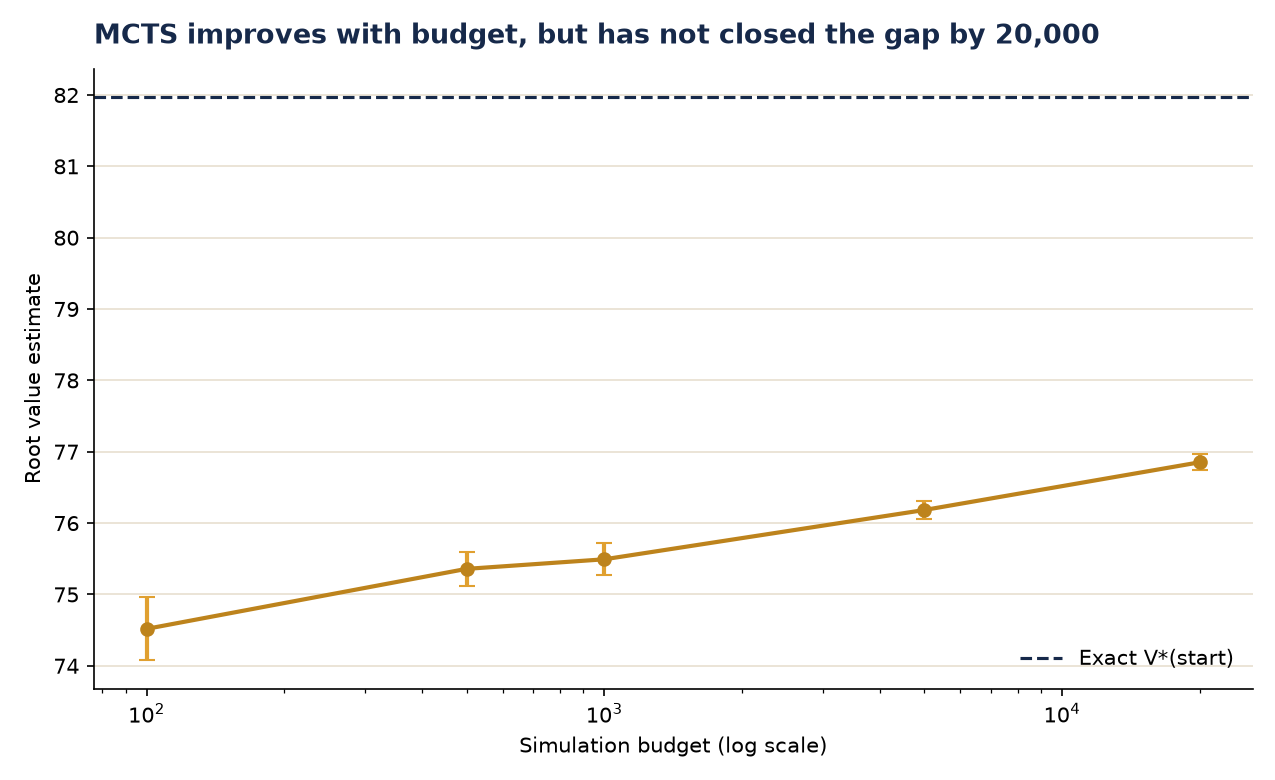

In [20]:
mcts.plot_convergence(conv_df, v_star, "../images/07_mcts_convergence.png")
Image("../images/07_mcts_convergence.png")

The root value estimate rises steadily with budget (74.5 at 100
simulations to 76.9 at 20,000), moving in the right direction, but a real
gap to the exact 82.0 remains even at the largest budget tested. The
reason shows up in the tree itself: with about four actions and several
stochastic outcomes each, the tree's width grows far faster than its
depth. At a budget of 20,000, most simulations exhaust the budget by
around week 6 to 8 of 12, meaning close to half of every simulated term
still falls back on a fully random rollout. That random tail drags the
average down, and it is exactly why the root's *value estimate*
undershoots even where, as the next check shows, its *recommended
action* is often still right.

### Policy agreement: how often does MCTS choose the same action?

In [21]:
agree_df = mcts.policy_agreement_experiment(V, policy, n_states=200, budget=2000)
agree_df.to_csv("../data/mcts_policy_agreement.csv", index=False)

agreement_rate = agree_df.agree.mean()
print(f"Sampled states: {len(agree_df)}")
print(f"Agreement rate: {agreement_rate:.1%} ({agree_df.agree.sum()} of {len(agree_df)})")

disagreements = agree_df[~agree_df.agree]
print(f"\nDisagreements: {len(disagreements)}")
print(f"Mean value lost on disagreement: {disagreements.value_lost.mean():.4f}")
print(f"Max value lost on disagreement: {disagreements.value_lost.max():.4f}")

Sampled states: 200
Agreement rate: 76.5% (153 of 200)

Disagreements: 47
Mean value lost on disagreement: 0.1494
Max value lost on disagreement: 0.8957


MCTS picks the exact optimal action about three quarters of the time
across 200 states sampled from the whole decision space (every
combination of week, knowledge, fatigue and tutoring sessions
remaining). Where it disagrees, the cost is small: on average a
fraction of a point, and less than one point even in the worst case
sampled. Near-ties, like the one at the start state above, make up most
of the disagreements: the wrong action is rarely a *bad* action, it is
usually the second-best one.

### Online performance: MCTS replanning every week

In [22]:
n_traj = 100
online_budget = 1000
mcts_scores = mcts.simulate_mcts_online(start, n_traj, online_budget)
optimal_scores = mdp.simulate_policy(mdp.optimal_policy_fn(policy), n_traj, np.random.default_rng(0), start)

print(f"MCTS, replanning every week (budget {online_budget}, {n_traj} terms): mean {mcts_scores.mean():.2f}")
print(f"Exact optimal policy ({n_traj} terms):                          mean {optimal_scores.mean():.2f}")
print(f"Gap: {optimal_scores.mean() - mcts_scores.mean():.2f} points")

MCTS, replanning every week (budget 1000, 100 terms): mean 80.30
Exact optimal policy (100 terms):                          mean 82.80
Gap: 2.50 points


Replanning every week closes much of the gap the convergence chart
showed. That makes sense: once several weeks have passed, the *remaining*
horizon MCTS has to search is much shorter than the full 12 weeks, so the
same 1,000 simulation budget reaches a far greater share of what is left
to plan, especially near the end of term. Searching the whole term once
from the start is a harder problem than searching whatever is left of it
each week.

### Scale-up: does exact DP stay practical at a larger size?

In [23]:
scale_result = mcts.scale_up_experiment(scaled_t_max=24, scaled_k_max=30, mcts_budget=5000)
for key, value in scale_result.items():
    print(f"{key}: {value}")

original_states: 2145
scaled_states: 11625
original_dp_time: 0.018736204000106227
scaled_dp_time: 0.09752533500000027
original_mcts_time: 1.3965652829999726
scaled_mcts_time: 2.640111434000005
mcts_budget: 5000


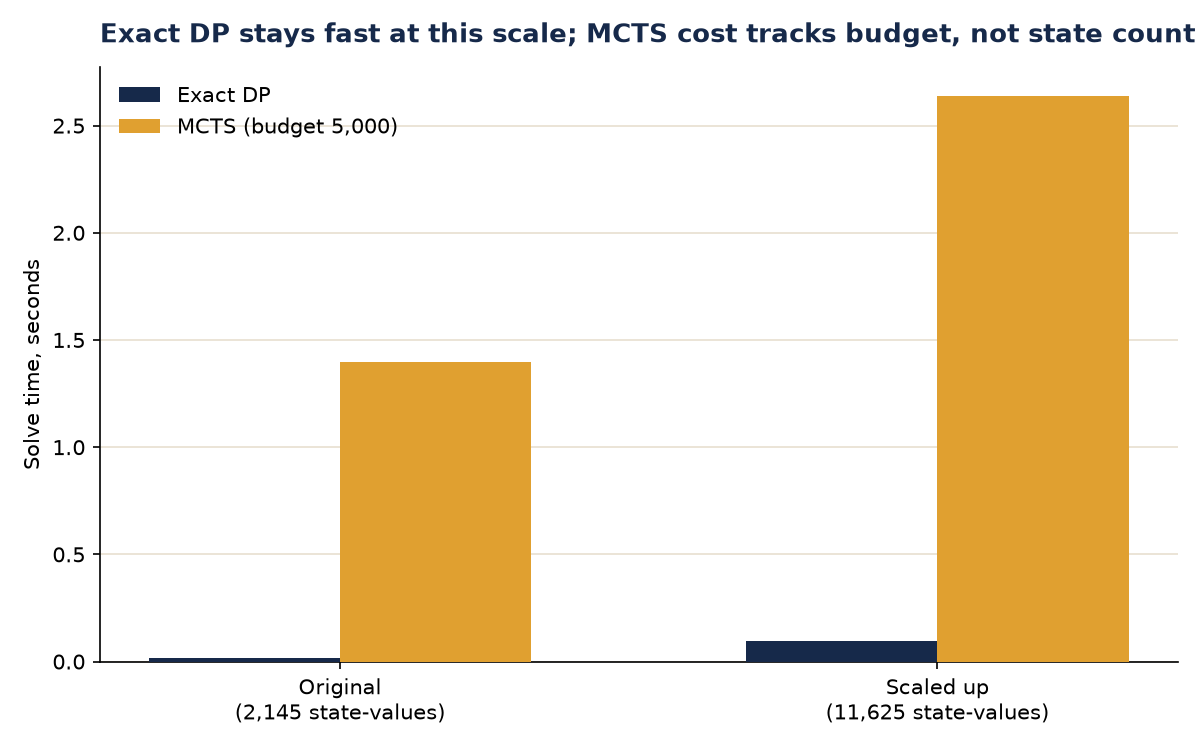

In [24]:
mcts.plot_scale_up(scale_result, "../images/08_mcts_scale_up.png")
Image("../images/08_mcts_scale_up.png")

Honestly: exact backward induction is still fast here. Doubling the
term to 24 weeks and tripling the knowledge scale to 0 to 30 multiplies
the state space by about 5.4 times (2,145 to 11,625 state-values), and
the exact solve time grows from 0.02 to about 0.1 seconds, both
negligible. MCTS, in contrast, costs roughly the same regardless of the
state-space size, since its cost is set by the search budget and the
horizon depth, not by how many states exist in total.

This is not a contradiction of MCTS's usual selling point, it is a
reminder of the condition behind it: tabular dynamic programming only
becomes impractical once the state space grows too large to enumerate at
all, which happens when new, largely independent state variables are
added (tracking several subjects' knowledge separately, say, rather than
one), not simply from a longer term or a finer knowledge scale along the
dimensions already here. At the size actually modelled in this project,
the honest conclusion is that exact DP remains the right tool, and MCTS's
value lies in not needing the transition model solved in closed form,
which matters once that model itself becomes too large or too expensive
to write down in full.

## 5. Risk-sensitive extension

**Plain-language finding first:** aiming to clear a specific grade rather
than maximise the average leads to a genuinely different policy, not
just a relabelling of the same one: 116 of 1,980 states (5.9%) choose a
different action, including the very first decision of the term. But the
practical difference in outcomes is small and exactly where you would
expect it: the target-grade policy trades a sliver of average score
(81.78 against 81.82) for a slightly better chance of clearing 70 (85.5%
against 85.3%) and a noticeably better worst case (5th percentile score
63.7 against 63.1).

### Target-grade terminal reward

$$
P(\text{score} \ge 70 \mid k) = \Phi\!\left( \frac{a + bk - 70}{\sigma} \right)
$$

where $a + bk$ is the same expected-score formula used throughout (45 at
$k = 0$, 95 at $k = 10$), $\sigma = 7.5$ is Project I's true exam noise,
and $\Phi$ is the standard normal CDF. Re-solving the identical Bellman
equation with this terminal reward, instead of the raw expected score,
gives the policy that maximises the *probability* of reaching the target
grade rather than the average grade itself.

In [25]:
import importlib
risk = importlib.import_module("04_risk_extension")

V_risk, policy_risk, _ = risk.solve_risk_sensitive()
print(f"Action at the start state, expected-score policy: {policy[0][start]}")
print(f"Action at the start state, target-grade policy:  {policy_risk[0][start]}")

n_diff = risk.count_disagreements(policy, policy_risk)
total_states = len(policy) * len(list(mdp.all_states()))
print(f"\nStates where the two policies choose a different action: "
      f"{n_diff} of {total_states} ({n_diff / total_states:.1%})")

Action at the start state, expected-score policy: group_study
Action at the start state, target-grade policy:  tutoring

States where the two policies choose a different action: 116 of 1980 (5.9%)


### Does this hold at other target grades?

In [26]:
sweep_df = risk.threshold_sweep(policy, targets=[50, 55, 60, 65, 70, 75, 80, 85, 90])
sweep_df.to_csv("../data/risk_threshold_sweep.csv", index=False)
sweep_df

,target,states_differing
0,50,113
1,55,121
2,60,101
3,65,107
4,70,116
5,75,139
6,80,143
7,85,157
8,90,188


The two policies differ at every threshold tested, from about 100 to
190 states out of 1,980, generally growing at higher targets: aiming for
90 is a much more demanding, and more distinctly cautious, goal than
aiming for 50, which most paths clear comfortably regardless of policy.
There is no threshold in this range where the policies coincide
exactly.

### Simulated outcomes: the actual trade-off

In [27]:
rng_ev = np.random.default_rng(mdp.common.SEED)
rng_risk = np.random.default_rng(mdp.common.SEED + 1)
n_sims = 10_000

scores_ev = risk.simulate_noisy_scores(mdp.optimal_policy_fn(policy), n_sims, rng_ev, start)
scores_risk = risk.simulate_noisy_scores(mdp.optimal_policy_fn(policy_risk), n_sims, rng_risk, start)

summary_ev = risk.summarise(scores_ev)
summary_risk = risk.summarise(scores_risk)

comparison = pd.DataFrame([
    {"policy": "Expected-score", **summary_ev},
    {"policy": "Target-grade", **summary_risk},
])
comparison.to_csv("../data/risk_comparison.csv", index=False)
comparison

,policy,mean,p_reach_target,p5,worst_decile_mean
0,Expected-score,81.819143,0.8529,63.095752,62.053686
1,Target-grade,81.780376,0.8552,63.717804,62.380359


Both policies land at almost the same mean score, since the target
grade of 70 sits well within reach of this student's typical outcome
either way. The target-grade policy's real advantage shows up in the
tail: a higher 5th percentile score and a better average among the worst
10% of simulated terms, exactly the protection a risk-sensitive
objective is meant to buy, at the cost of essentially nothing in the
average case here.

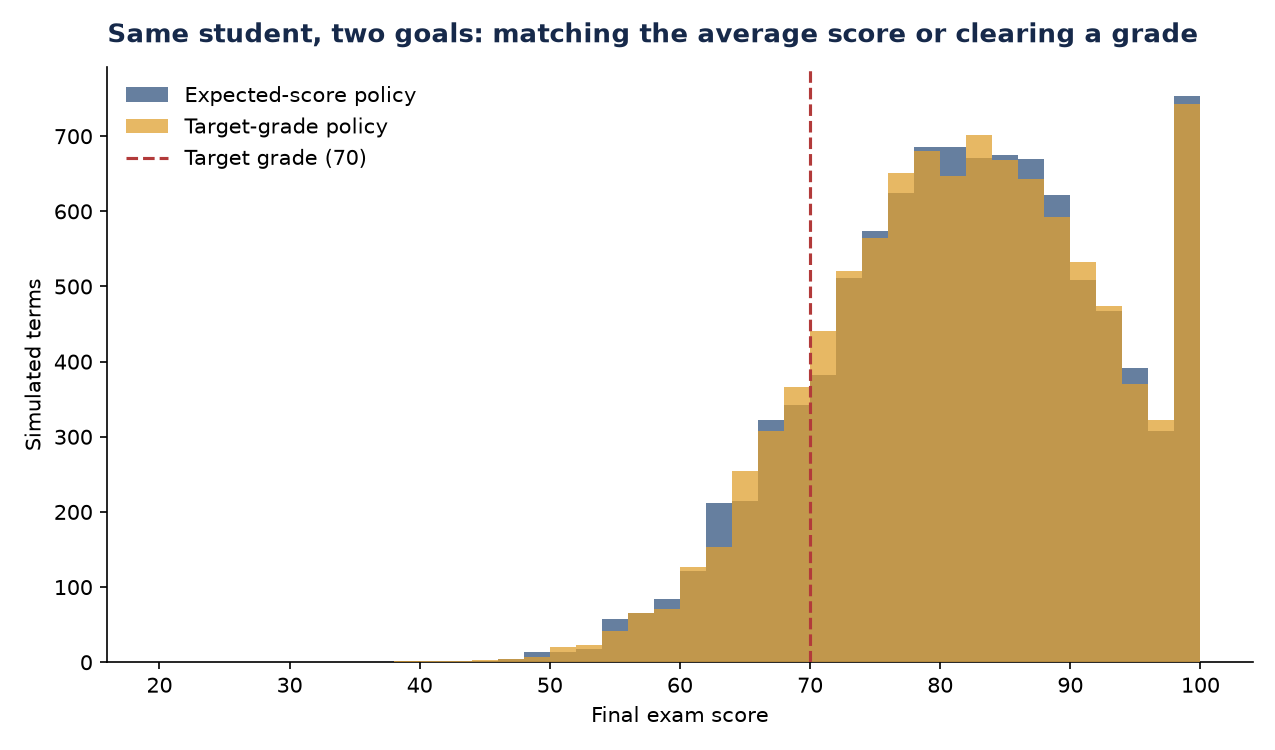

In [28]:
from IPython.display import Image

risk.plot_score_distributions(scores_ev, scores_risk, mdp.common.RISK_TARGET_GRADE,
                                "../images/09_risk_score_distributions.png")
Image("../images/09_risk_score_distributions.png")

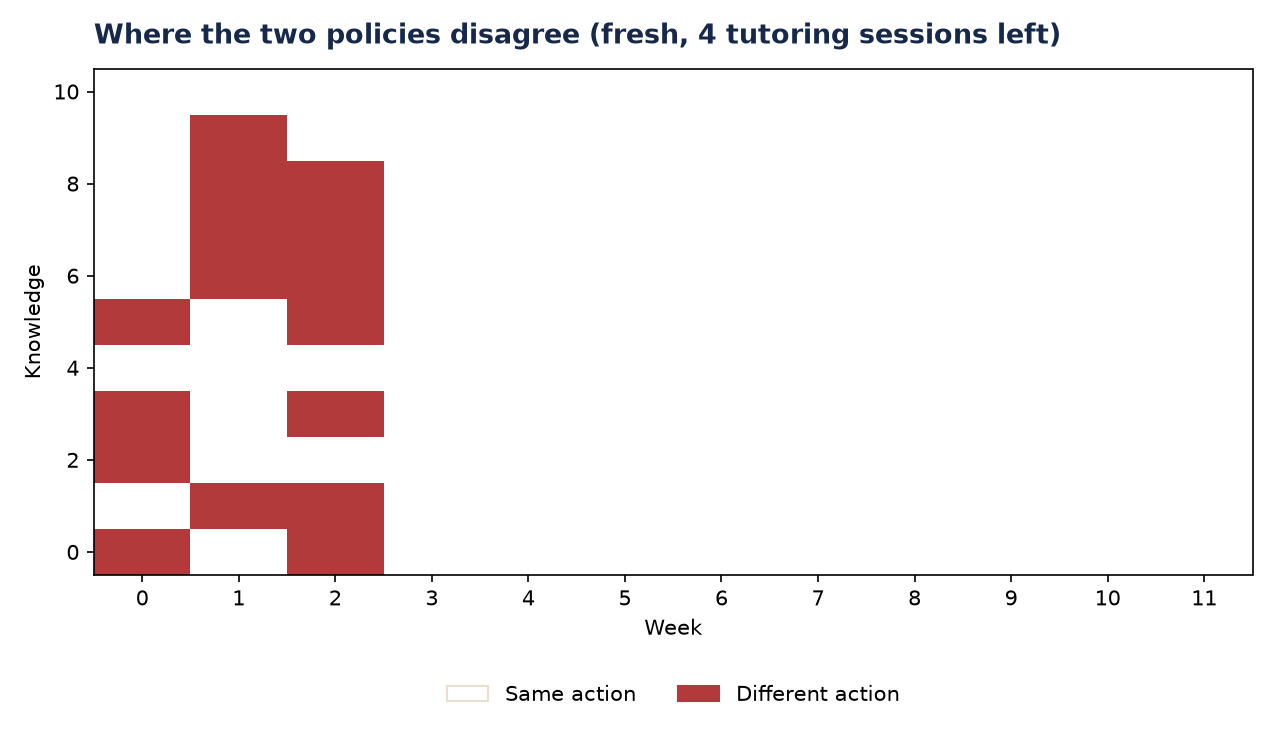

In [29]:
risk.plot_policy_diff_heatmap(policy, policy_risk, f=0, s=4,
                               path="../images/10_risk_policy_diff_fresh_full_sessions.png",
                               title="Where the two policies disagree (fresh, 4 tutoring sessions left)")
Image("../images/10_risk_policy_diff_fresh_full_sessions.png")

Fresh at the start of term, the two policies disagree only in the
first two or three weeks; from week 3 onward, with this fatigue and
session count, they always choose the same action. The risk-sensitive
objective changes the opening moves, not the whole-term strategy.

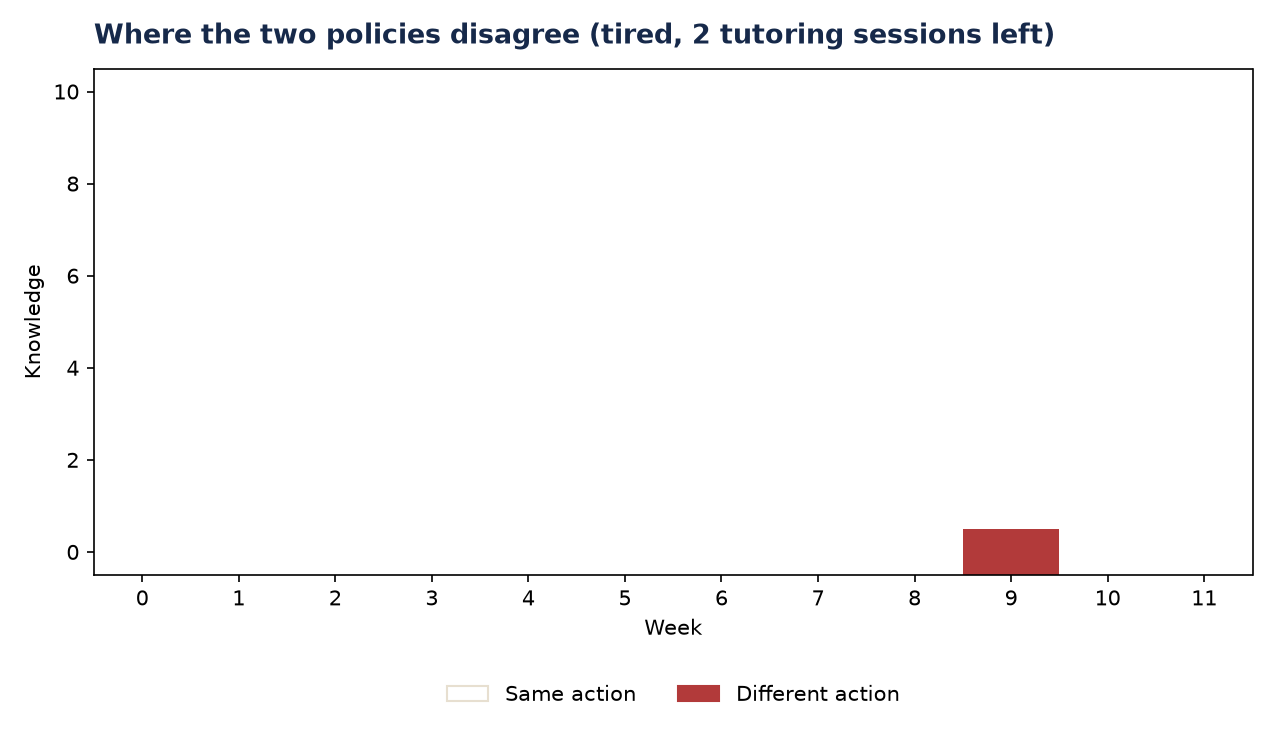

In [30]:
risk.plot_policy_diff_heatmap(policy, policy_risk, f=1, s=2,
                               path="../images/11_risk_policy_diff_tired_some_sessions.png",
                               title="Where the two policies disagree (tired, 2 tutoring sessions left)")
Image("../images/11_risk_policy_diff_tired_some_sessions.png")

Starting tired with sessions already partly used, the two policies
agree almost everywhere, disagreeing at only a single state late in the
term. The size of the disagreement depends heavily on where a student
already stands, not just on which objective is used.

This is one simple form of risk-sensitive decision-making: maximising the
probability of clearing a fixed threshold. More general approaches, such
as optimising a risk measure like CVaR (the expected shortfall in the
worst outcomes, rather than just their probability), are a natural next
step beyond what is modelled here.

## 6. Results

*To be built in Phase 6.*

## 7. Recommendations

*To be built in Phase 6.*